<a href="https://colab.research.google.com/github/RishikaBhawsingka/NLP-ML-project/blob/main/BERT_note7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q -U transformers datasets accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 109.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 19.3 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import ast
import numpy as np
import pandas as pd
import torch

from datasets import Dataset

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

In [ ]:
print("CUDA Available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

CUDA Available : True
GPU : Tesla T4


In [ ]:
BASE_DIR = "/content/drive/MyDrive/HumanBehaviourSimulator"

DATASET_DIR = os.path.join(BASE_DIR, "datasets")
MODEL_DIR = os.path.join(BASE_DIR, "models")
REPORT_DIR = os.path.join(BASE_DIR, "reports")
BERT_PLOTS_DIR = os.path.join(BASE_DIR, "plots", "BERT")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)
os.makedirs(BERT_PLOTS_DIR, exist_ok=True)

print("✅ Paths Ready")

✅ Paths Ready


In [ ]:
train = pd.read_csv(
    os.path.join(DATASET_DIR, "train.csv"),
    keep_default_na=False
)

validation = pd.read_csv(
    os.path.join(DATASET_DIR, "validation.csv"),
    keep_default_na=False
)

test = pd.read_csv(
    os.path.join(DATASET_DIR, "test.csv"),
    keep_default_na=False
)

print(train.shape)
print(validation.shape)
print(test.shape)

(43410, 3)
(5426, 3)
(5427, 3)


In [ ]:
#converting labels list to integer
train["labels"] = train["labels"].apply(lambda x: ast.literal_eval(x)[0])
validation["labels"] = validation["labels"].apply(lambda x: ast.literal_eval(x)[0])
test["labels"] = test["labels"].apply(lambda x: ast.literal_eval(x)[0])

print(train["labels"].head())
print(type(train["labels"].iloc[0]))

0    27
1    27
2     2
3    14
4     3
Name: labels, dtype: int64
<class 'numpy.int64'>


In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
train_dataset = Dataset.from_pandas(train)
validation_dataset = Dataset.from_pandas(validation)
test_dataset = Dataset.from_pandas(test)

print("✅ Hugging Face Datasets Created")

✅ Hugging Face Datasets Created


In [ ]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

print("✅ Tokenizer Loaded")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

✅ Tokenizer Loaded


In [ ]:
def tokenize(batch):

    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

In [ ]:
train_dataset = train_dataset.map(tokenize, batched=True)
validation_dataset = validation_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

print("✅ Tokenization Completed")

Map:   0%|          | 0/43410 [00:00<?, ? examples/s]

Map:   0%|          | 0/5426 [00:00<?, ? examples/s]

Map:   0%|          | 0/5427 [00:00<?, ? examples/s]

✅ Tokenization Completed


In [ ]:
train_dataset = train_dataset.remove_columns(["text", "id"])
validation_dataset = validation_dataset.remove_columns(["text", "id"])
test_dataset = test_dataset.remove_columns(["text", "id"])

print(train_dataset.column_names)

['labels', 'input_ids', 'token_type_ids', 'attention_mask']


In [ ]:
train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "token_type_ids", "labels"]
)

validation_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "token_type_ids", "labels"]
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "token_type_ids", "labels"]
)

print("✅ Dataset Ready for PyTorch")

✅ Dataset Ready for PyTorch


In [ ]:
print(train_dataset.column_names)
print("Training Samples :", len(train_dataset))
print("Validation Samples :", len(validation_dataset))
print("Test Samples :", len(test_dataset))

['labels', 'input_ids', 'token_type_ids', 'attention_mask']
Training Samples : 43410
Validation Samples : 5426
Test Samples : 5427


In [ ]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=28
)

print("✅ BERT Model Loaded")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ BERT Model Loaded


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(

    output_dir="./bert_results",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=2,

    weight_decay=0.01,

    logging_steps=100,

    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,

    save_total_limit=1,

    report_to="none"
)

In [ ]:
#creating trainer
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,
    compute_metrics=compute_metrics
)

print("✅ Trainer Ready")

✅ Trainer Ready


In [ ]:
trainer.train() #training BERT model with GPU-T4

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.431875,1.406985,0.582934,0.573652,0.582934,0.560692
2,1.235746,1.370911,0.587173,0.570849,0.587173,0.570965


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=5428, training_loss=1.479250631353481, metrics={'train_runtime': 2078.5051, 'train_samples_per_second': 41.77, 'train_steps_per_second': 2.611, 'total_flos': 5712158611722240.0, 'train_loss': 1.479250631353481, 'epoch': 2.0})

In [ ]:
test_results = trainer.evaluate(test_dataset)

print("\n" + "="*50)
print("📊 BERT - Test Results")
print("="*50)

print(f"Accuracy : {test_results['eval_accuracy']:.4f}")
print(f"Precision: {test_results['eval_precision']:.4f}")
print(f"Recall   : {test_results['eval_recall']:.4f}")
print(f"F1 Score : {test_results['eval_f1']:.4f}")

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
1.235746,1.374871,2,0.587249,0.572429,0.587249,0.572353



📊 BERT - Test Results
Accuracy : 0.5872
Precision: 0.5724
Recall   : 0.5872
F1 Score : 0.5724


In [ ]:
import numpy as np

predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)

y_true = predictions.label_ids

print("Prediction Shape :", y_pred.shape)
print("Ground Truth Shape :", y_true.shape)

Prediction Shape : (5427,)
Ground Truth Shape : (5427,)


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm.shape)

(28, 28)


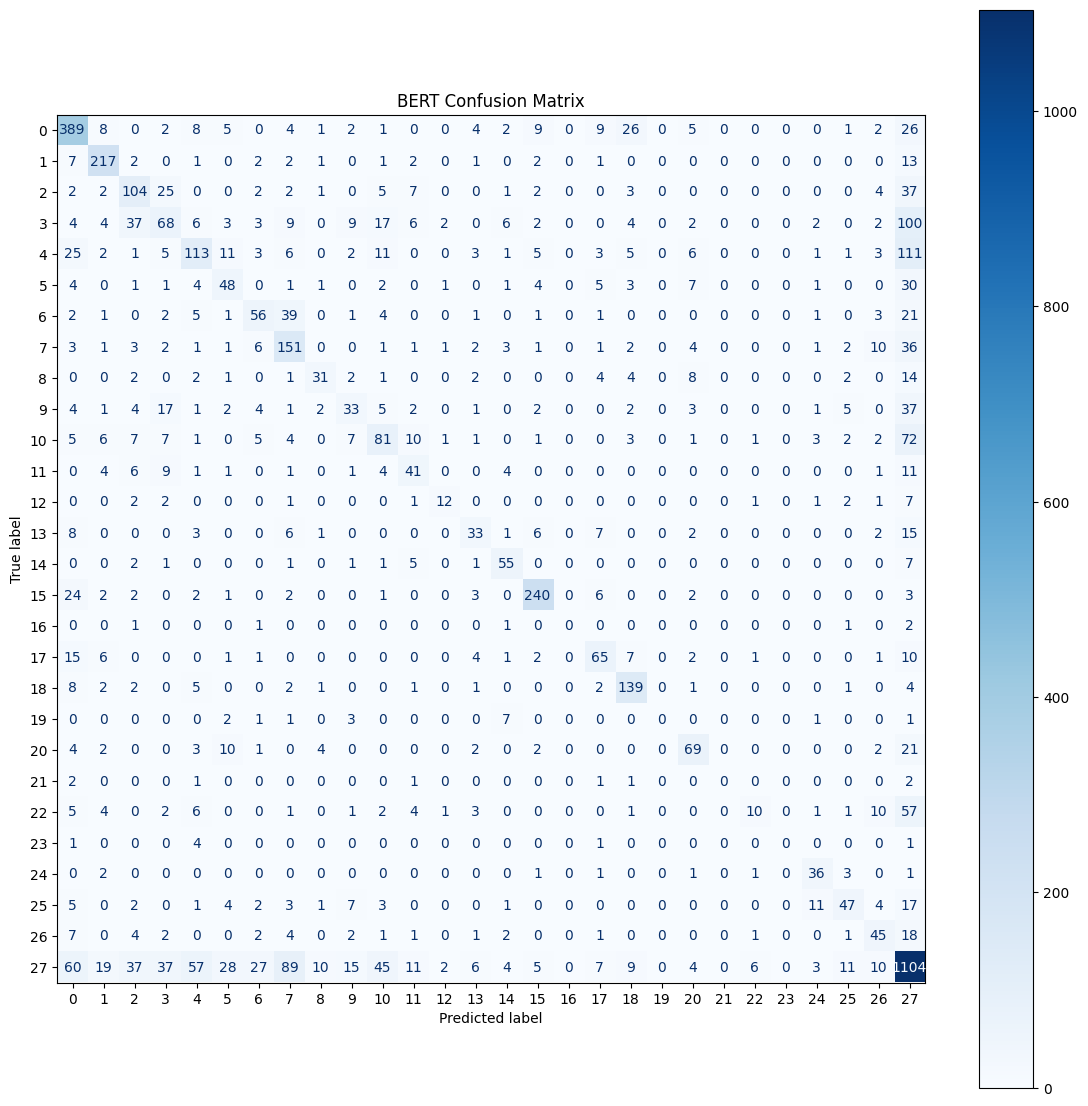

In [ ]:
#plotting
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(14,14))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=True,
    values_format="d"
)

plt.title("BERT Confusion Matrix")

plt.savefig(
    os.path.join(BERT_PLOTS_DIR, "Confusion_Matrix.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    digits=4,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

           0     0.6661    0.7718    0.7151       504
           1     0.7668    0.8611    0.8112       252
           2     0.4749    0.5279    0.5000       197
           3     0.3736    0.2378    0.2906       286
           4     0.5022    0.3553    0.4162       318
           5     0.4034    0.4211    0.4120       114
           6     0.4828    0.4029    0.4392       139
           7     0.4562    0.6481    0.5355       233
           8     0.5741    0.4189    0.4844        74
           9     0.3837    0.2598    0.3099       127
          10     0.4355    0.3682    0.3990       220
          11     0.4409    0.4881    0.4633        84
          12     0.6000    0.4000    0.4800        30
          13     0.4783    0.3929    0.4314        84
          14     0.6111    0.7432    0.6707        74
          15     0.8421    0.8333    0.8377       288
          16     0.0000    0.0000    0.0000         6
          17     0.5652    

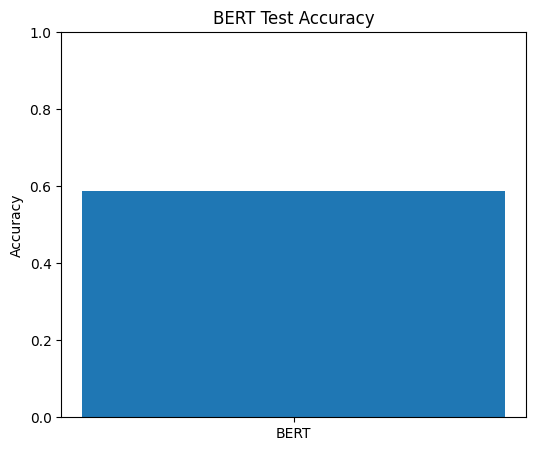

In [ ]:
plt.figure(figsize=(6,5))

plt.bar(
    ["BERT"],
    [0.5872]
)

plt.ylim(0,1)

plt.ylabel("Accuracy")

plt.title("BERT Test Accuracy")

plt.savefig(
    os.path.join(BERT_PLOTS_DIR, "Accuracy.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

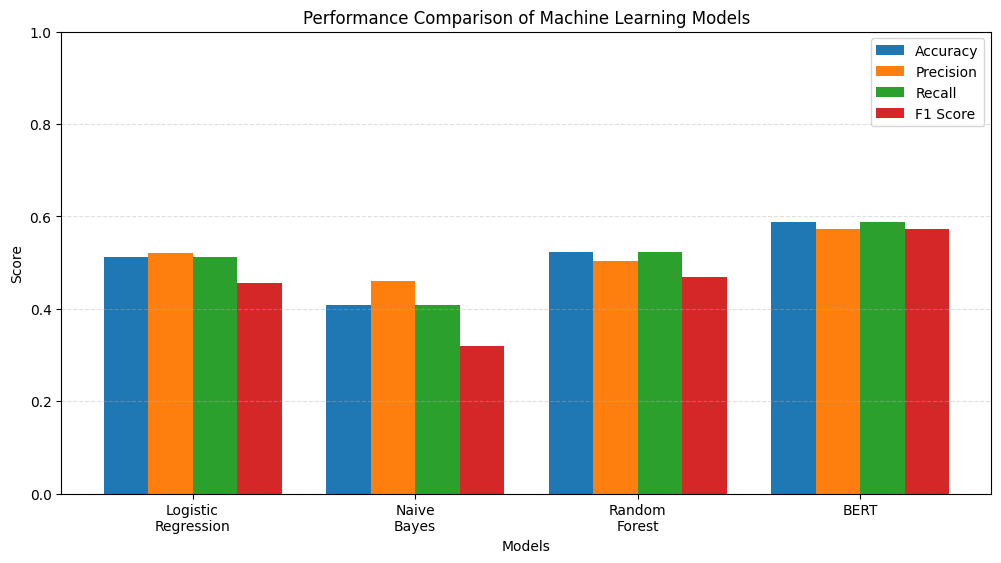

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Metrics
models = ["Logistic\nRegression", "Naive\nBayes", "Random\nForest", "BERT"]

accuracy = [0.5126, 0.4070, 0.5217, 0.5872]
precision = [0.5213, 0.4592, 0.5034, 0.5724]
recall = [0.5126, 0.4070, 0.5217, 0.5872]
f1 = [0.4562, 0.3203, 0.4677, 0.5724]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(12,6))

plt.bar(x - 1.5*width, accuracy, width, label="Accuracy")
plt.bar(x - 0.5*width, precision, width, label="Precision")
plt.bar(x + 0.5*width, recall, width, label="Recall")
plt.bar(x + 1.5*width, f1, width, label="F1 Score")

plt.xticks(x, models)
plt.ylim(0, 1)

plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Performance Comparison of Machine Learning Models")

plt.legend()

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.savefig(
    os.path.join(BASE_DIR, "plots", "Model_Comparison.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import os

# Folder to save model
BERT_MODEL_DIR = os.path.join(MODEL_DIR, "BERT_Model")

os.makedirs(BERT_MODEL_DIR, exist_ok=True)

# Save model
trainer.save_model(BERT_MODEL_DIR)

# Save tokenizer
tokenizer.save_pretrained(BERT_MODEL_DIR)

print("✅ BERT model saved successfully!")
print(BERT_MODEL_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ BERT model saved successfully!
/content/drive/MyDrive/HumanBehaviourSimulator/models/BERT_Model


In [ ]:
!pip install python-docx
from docx import Document
from docx.shared import Pt
import os

doc = Document()

# -----------------------------
# Title
# -----------------------------
title = doc.add_heading("Experiment 04 - BERT Emotion Classification", level=1)
title.runs[0].font.size = Pt(18)

# -----------------------------
# Objective
# -----------------------------
doc.add_heading("1. Objective", level=2)

doc.add_paragraph(
    "To fine-tune a pre-trained BERT model for multi-class emotion "
    "classification and compare its performance with Logistic Regression, "
    "Naive Bayes, and Random Forest."
)

# -----------------------------
# Dataset
# -----------------------------
doc.add_heading("2. Dataset", level=2)

doc.add_paragraph(
    "Dataset : GoEmotions\n"
    "Training Samples : 43,410\n"
    "Validation Samples : 5,426\n"
    "Test Samples : 5,427\n"
    "Total Emotion Classes : 28"
)

# -----------------------------
# Model
# -----------------------------
doc.add_heading("3. Model Used", level=2)

doc.add_paragraph(
    "Model : bert-base-uncased\n"
    "Framework : Hugging Face Transformers\n"
    "Tokenizer : BertTokenizer\n"
    "Loss Function : Cross Entropy Loss\n"
    "Optimizer : AdamW"
)

# -----------------------------
# Training Configuration
# -----------------------------
doc.add_heading("4. Training Configuration", level=2)

doc.add_paragraph(
    "Learning Rate : 2e-5\n"
    "Epochs : 2\n"
    "Batch Size : 16\n"
    "Weight Decay : 0.01\n"
    "Evaluation Strategy : Every Epoch\n"
    "GPU : Tesla T4"
)

# -----------------------------
# Validation Results
# -----------------------------
doc.add_heading("5. Validation Results", level=2)

table = doc.add_table(rows=5, cols=2)
table.style = "Table Grid"

table.cell(0,0).text = "Metric"
table.cell(0,1).text = "Value"

table.cell(1,0).text = "Accuracy"
table.cell(1,1).text = "0.5872"

table.cell(2,0).text = "Precision"
table.cell(2,1).text = "0.5724"

table.cell(3,0).text = "Recall"
table.cell(3,1).text = "0.5872"

table.cell(4,0).text = "F1 Score"
table.cell(4,1).text = "0.5724"

# -----------------------------
# Test Results
# -----------------------------
doc.add_heading("6. Test Results", level=2)

table2 = doc.add_table(rows=5, cols=2)
table2.style = "Table Grid"

table2.cell(0,0).text = "Metric"
table2.cell(0,1).text = "Value"

table2.cell(1,0).text = "Accuracy"
table2.cell(1,1).text = "0.5872"

table2.cell(2,0).text = "Precision"
table2.cell(2,1).text = "0.5724"

table2.cell(3,0).text = "Recall"
table2.cell(3,1).text = "0.5872"

table2.cell(4,0).text = "F1 Score"
table2.cell(4,1).text = "0.5724"

# -----------------------------
# Comparison
# -----------------------------
doc.add_heading("7. Comparison with Previous Models", level=2)

comparison = doc.add_table(rows=5, cols=5)
comparison.style = "Table Grid"

comparison.cell(0,0).text = "Model"
comparison.cell(0,1).text = "Accuracy"
comparison.cell(0,2).text = "Precision"
comparison.cell(0,3).text = "Recall"
comparison.cell(0,4).text = "F1"

models = [
    ("Logistic Regression","0.5126","0.5213","0.5126","0.4562"),
    ("Naive Bayes","0.4070","0.4592","0.4070","0.3203"),
    ("Random Forest","0.5217","0.5034","0.5217","0.4677"),
    ("BERT","0.5872","0.5724","0.5872","0.5724")
]

for i, row in enumerate(models, start=1):
    for j, value in enumerate(row):
        comparison.cell(i,j).text = value

# -----------------------------
# Findings
# -----------------------------
doc.add_heading("8. Findings", level=2)

doc.add_paragraph(
    "• BERT achieved the highest accuracy among all models.\n"
    "• Contextual word embeddings significantly improved emotion classification.\n"
    "• Fine-tuning a pre-trained transformer outperformed traditional machine learning models.\n"
    "• BERT showed the best balance between Accuracy, Precision, Recall and F1 Score."
)

# -----------------------------
# Conclusion
# -----------------------------
doc.add_heading("9. Conclusion", level=2)

doc.add_paragraph(
    "The fine-tuned BERT model produced the best overall performance with an "
    "accuracy of 58.72%. Compared to Logistic Regression, Naive Bayes, and "
    "Random Forest, BERT demonstrated superior contextual understanding of "
    "text, making it the most suitable model for the Human Behaviour Simulator."
)

# -----------------------------
# Save
# -----------------------------
report_path = os.path.join(
    REPORT_DIR,
    "Experiment_04_BERT_Report.docx"
)

doc.save(report_path)

print("✅ Report Saved Successfully")
print(report_path)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 3.1 MB/s eta 0:00:00
✅ Report Saved Successfully
/content/drive/MyDrive/HumanBehaviourSimulator/reports/Experiment_04_BERT_Report.docx


In [ ]:
from docx import Document
import os

# Existing project documentation
project_doc_path = os.path.join(
    BASE_DIR,
    "Project_Documentation.docx"
)

doc = Document(project_doc_path)

# -------------------------------------------------
# NOTEBOOK 7
# -------------------------------------------------

doc.add_heading("Notebook 7: BERT Emotion Classification", level=1)

doc.add_paragraph(
    "In this notebook, a pre-trained BERT (bert-base-uncased) model was "
    "fine-tuned for multi-class emotion classification using the GoEmotions "
    "dataset. The dataset was tokenized using the BERT tokenizer and trained "
    "for two epochs on a Tesla T4 GPU using the Hugging Face Transformers "
    "library. The model achieved the highest performance among all evaluated "
    "models."
)

doc.add_heading("Results", level=2)

table = doc.add_table(rows=5, cols=2)
table.style = "Table Grid"

table.cell(0,0).text = "Metric"
table.cell(0,1).text = "Value"

table.cell(1,0).text = "Accuracy"
table.cell(1,1).text = "58.72%"

table.cell(2,0).text = "Precision"
table.cell(2,1).text = "57.24%"

table.cell(3,0).text = "Recall"
table.cell(3,1).text = "58.72%"

table.cell(4,0).text = "F1 Score"
table.cell(4,1).text = "57.24%"

# -------------------------------------------------
# OVERALL COMPARISON
# -------------------------------------------------

doc.add_page_break()

doc.add_heading("Overall Model Comparison", level=1)

comparison = doc.add_table(rows=5, cols=5)
comparison.style = "Table Grid"

comparison.cell(0,0).text = "Model"
comparison.cell(0,1).text = "Accuracy"
comparison.cell(0,2).text = "Precision"
comparison.cell(0,3).text = "Recall"
comparison.cell(0,4).text = "F1 Score"

models = [
    ["Logistic Regression","51.26%","52.13%","51.26%","45.62%"],
    ["Naive Bayes","40.70%","45.92%","40.70%","32.03%"],
    ["Random Forest","52.17%","50.34%","52.17%","46.77%"],
    ["BERT","58.72%","57.24%","58.72%","57.24%"]
]

for i,row in enumerate(models,1):
    for j,val in enumerate(row):
        comparison.cell(i,j).text = val

doc.add_heading("Model Analysis", level=2)

doc.add_paragraph(
    "• Logistic Regression served as a strong baseline and produced stable performance using TF-IDF features.\n"
    "• Naive Bayes trained very quickly but produced the lowest accuracy because of its conditional independence assumption.\n"
    "• Random Forest slightly improved over Logistic Regression by learning non-linear relationships, but it still relied on TF-IDF representations.\n"
    "• BERT significantly outperformed all traditional machine learning models by leveraging contextual word embeddings and attention mechanisms, enabling a better understanding of sentence meaning."
)

# -------------------------------------------------
# FINAL CONCLUSION
# -------------------------------------------------

doc.add_heading("Final Conclusion", level=1)

doc.add_paragraph(
    "This project successfully implemented and evaluated four different "
    "approaches for multi-class emotion classification: Logistic Regression, "
    "Naive Bayes, Random Forest, and BERT. Each experiment followed a complete "
    "machine learning workflow including data preprocessing, feature preparation, "
    "model training, validation, testing, visualization, and performance analysis."
)

doc.add_paragraph(
    "Among all evaluated models, the fine-tuned BERT model achieved the best "
    "overall performance with a test accuracy of 58.72% and an F1 Score of "
    "57.24%. Its contextual understanding of language enabled more accurate "
    "emotion prediction than traditional machine learning algorithms based on "
    "TF-IDF features."
)

doc.add_paragraph(
    "The project demonstrates that while traditional machine learning models "
    "provide efficient and interpretable baselines, transformer-based deep "
    "learning models are more effective for complex Natural Language Processing "
    "tasks involving emotion recognition."
)

doc.add_heading("Future Scope", level=2)

doc.add_paragraph(
    "Future improvements may include experimenting with RoBERTa, DeBERTa or "
    "DistilBERT models, applying hyperparameter optimization, addressing class "
    "imbalance, performing data augmentation, deploying the trained model as a "
    "web application, and integrating the emotion classifier into the Human "
    "Behaviour Simulator for real-time behavioural prediction."
)

# -------------------------------------------------
# SAVE
# -------------------------------------------------

doc.save(project_doc_path)

print("✅ Project_Documentation.docx updated successfully!")
print(project_doc_path)

✅ Project_Documentation.docx updated successfully!
/content/drive/MyDrive/HumanBehaviourSimulator/Project_Documentation.docx


In [ ]:
from openpyxl import load_workbook
import os

# Excel file path
excel_path = os.path.join(BASE_DIR, "Experiment_Log.xlsx")

# Load workbook
wb = load_workbook(excel_path)
ws = wb.active

# -------------------------------------------------------
# Columns
# A  Experiment
# B  Date
# C  Notebook
# D  Model
# E  Dataset
# F  Features
# G  Accuracy
# H  Precision
# I  Recall
# J  F1 Score
# K  Training Time
# L  Observations
# M  Next Improvement
# -------------------------------------------------------

experiments = [

    [
        "Experiment 01",
        "2026-07-22",
        "Notebook 4",
        "Logistic Regression",
        "GoEmotions",
        "TF-IDF (5000 Features)",
        0.5126,
        0.5213,
        0.5126,
        0.4562,
        "~2 min",
        "Strong baseline model with balanced performance.",
        "Hyperparameter tuning and feature engineering."
    ],

    [
        "Experiment 02",
        "2026-07-23",
        "Notebook 5",
        "Naive Bayes",
        "GoEmotions",
        "TF-IDF (5000 Features)",
        0.4070,
        0.4592,
        0.4070,
        0.3203,
        "<1 min",
        "Fastest model but lowest accuracy due to independence assumption.",
        "Improve using contextual embeddings."
    ],

    [
        "Experiment 03",
        "2026-07-24",
        "Notebook 6",
        "Random Forest",
        "GoEmotions",
        "TF-IDF (5000 Features)",
        0.5217,
        0.5034,
        0.5217,
        0.4677,
        "~7 min",
        "Captured non-linear relationships with slight improvement.",
        "Increase trees or use ensemble boosting."
    ],

    [
        "Experiment 04",
        "2026-07-24",
        "Notebook 7",
        "BERT",
        "GoEmotions",
        "BERT Tokenizer + Contextual Embeddings",
        0.5872,
        0.5724,
        0.5872,
        0.5724,
        "~35 min (Tesla T4)",
        "Best performing model with contextual language understanding.",
        "Try RoBERTa, DeBERTa or hyperparameter tuning."
    ]
]

start_row = 2

for i, exp in enumerate(experiments, start=start_row):
    for j, value in enumerate(exp, start=1):
        ws.cell(row=i, column=j).value = value

wb.save(excel_path)

print("✅ Experiment_Log.xlsx updated successfully!")
print(excel_path)

✅ Experiment_Log.xlsx updated successfully!
/content/drive/MyDrive/HumanBehaviourSimulator/Experiment_Log.xlsx
